# Multi-Experiment Benchmark: Causal vs Traditional ML Under Point-Wise Interventions

This notebook evaluates causal vs traditional ML models using **point-wise interventions** across **4 different equation sets** (A2C, B1C, C2C, D2C).

**Experiments:**
| Name | Vars | Max Lag | Equations | Confounder |
|------|------|---------|-----------|------------|
| **A2C** | 6 | 2 | Linear | U ✓ |
| **B1C** | 4 | 4 | Nonlinear poly (x², x³) | U ✓ |
| **C2C** | 6 | 4 | Trigonometric + trend + season | — |
| **D2C** | 4 | 4 | Nonlinear poly (x², x³) | U ✓ |

**Consistent across all experiments:**
- **Intervention**: `do(X3 = v)` — set X3 to a random value `v`
- **Target**: predict `X2` (structural link: X3[t-1] → X2[t])
- **Ground truth**: `GT = X2_obs + struct_fn(v) − struct_fn(X3_lag1_obs)` (residual + counterfactual)
- **Traditional**: replaces all X3 lags with `v`, predicts X2 directly
- **Causal**: sets X3 lags to `v`, propagates through the causal graph (`what_if=True`)

**Final result**: per-experiment MAE + median across all 4 experiments.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from scipy import stats

import utils as ut
import model_wrappers as mw

current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
print("Setup complete.")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Setup complete.


## 1. DGP Generators (A2C · B1C · C2C · D2C)

Each generator produces a pandas DataFrame where rows are time steps and columns are the variables.
- **A2C** (linear, 6 vars): standard linear SCM with confounder U
- **B1C** (nonlinear poly, 4 vars): polynomial (x², x³) perturbations with confounder U
- **C2C** (trig + trend/season, 6 vars): sin/cos functional forms plus deterministic trend and seasonality, no U
- **D2C** (nonlinear poly, 4 vars): same polynomial structure as B1C with confounder U


In [ ]:
def _trend(amp, t, n_total):
    """Linear deterministic trend component."""
    return amp * t / n_total


def _season(amp, period, t):
    """Sinusoidal seasonality component."""
    return amp * np.sin(2 * np.pi * t / period)


# ─────────────────────────────────────────────────────────────────────────────
# A2C  –  6 variables, linear, max_lag = 2, with confounder U
# Equations:
#   X5[t] = e5  (exogenous)
#   X4[t] = 0.25*X1[t-2] + 0.3*X5[t-1] + e4
#   X3[t] = 0.35*X4[t]   + 0.3*U[t]    + e3
#   X2[t] = 0.3*X3[t-1]                 + e2
#   X1[t] = 0.4*X2[t]    + 0.5*U[t]    + e1
#   X6[t] = 0.85*X5[t]   + 0.4*U[t]    + e6
# ─────────────────────────────────────────────────────────────────────────────
def generate_A2C(n_points, noise_scale=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    max_lag = 2
    X = np.zeros((n_points, 6))  # cols: X1 X2 X3 X4 X5 X6
    U = np.zeros(n_points)

    for i in range(max_lag):
        X[i] = np.random.normal(0, noise_scale, 6)
        U[i] = np.random.normal(0, noise_scale)

    for t in range(max_lag, n_points):
        e = np.random.normal(0, noise_scale, 6)
        U[t] = np.random.normal(0, noise_scale)
        X[t, 4] = e[4]                                               # X5 exogenous
        X[t, 3] = 0.25 * X[t-2, 0] + 0.3 * X[t-1, 4] + e[3]       # X4
        X[t, 1] = 0.3  * X[t-1, 2] + e[1]                          # X2 (past only)
        X[t, 2] = 0.35 * X[t, 3]   + 0.3 * U[t]       + e[2]       # X3
        X[t, 0] = 0.4  * X[t, 1]   + 0.5 * U[t]       + e[0]       # X1
        X[t, 5] = 0.85 * X[t, 4]   + 0.4 * U[t]       + e[5]       # X6

    df = pd.DataFrame(X, columns=['X1', 'X2', 'X3', 'X4', 'X5', 'X6'])
    df['U'] = U
    return df


# ─────────────────────────────────────────────────────────────────────────────
# B1C  –  4 variables, nonlinear poly (x², x³), max_lag = 4, with confounder U
# Equations:
#   X4[t] = 0.25*X1[t-4]^2 - 0.1*X1[t-4]^3                                + e4
#   X3[t] = 0.35*X4[t]^2   - 0.15*X4[t]^3 + 0.2*X2[t-3]^2 + 0.3*U[t]^2   + e3
#   X2[t] = 0.3*X3[t-1]^2  - 0.05*X3[t-1]^3                                + e2
#   X1[t] = 0.4*X2[t]^2    - 0.2*X2[t]^3  + 0.5*U[t]^2                    + e1
# ─────────────────────────────────────────────────────────────────────────────
def generate_B1C(n_points, noise_scale=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    max_lag = 4
    X = np.zeros((n_points, 4))  # cols: X1 X2 X3 X4
    U = np.zeros(n_points)

    for i in range(max_lag):
        X[i] = np.random.normal(0, noise_scale, 4)
        U[i] = np.random.normal(0, noise_scale)

    for t in range(max_lag, n_points):
        e = np.random.normal(0, noise_scale, 4)
        U[t] = np.random.normal(0, noise_scale)
        X[t, 3] = 0.25 * X[t-4, 0]**2 - 0.1  * X[t-4, 0]**3 + e[3]           # X4
        X[t, 1] = 0.3  * X[t-1, 2]**2 - 0.05 * X[t-1, 2]**3 + e[1]           # X2 (past only)
        X[t, 2] = (0.35 * X[t, 3]**2 - 0.15 * X[t, 3]**3
                   + 0.2 * X[t-3, 1]**2 + 0.3 * U[t]**2 + e[2])               # X3
        X[t, 0] = 0.4 * X[t, 1]**2 - 0.2 * X[t, 1]**3 + 0.5 * U[t]**2 + e[0] # X1

    df = pd.DataFrame(X, columns=['X1', 'X2', 'X3', 'X4'])
    df['U'] = U
    return df


# ─────────────────────────────────────────────────────────────────────────────
# C2C  –  6 variables, trigonometric + trend + season, max_lag = 4, no U
# Equations:
#   X4[t] = 0.25*cos(X1[t-4]*π/2)          + trend4 + season4 + e4
#   X3[t] = 0.35*X4[t]^2 + 0.2*cos(X2[t-3]*π/2) + trend3 + season3 + e3
#   X2[t] = 0.3*sin(X3[t-1]*π/2)           + trend2 + season2 + e2
#   X1[t] = 0.4*X2[t]^3                    + trend1 + season1 + e1
#   X5[t] = 0.3*cos(X4[t-1]*π/2)           + trend5 + season5 + e5
#   X6[t] = 0.45*sin(X5[t]*π/2)            + trend6 + season6 + e6
# ─────────────────────────────────────────────────────────────────────────────
def generate_C2C(n_points, noise_scale=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    max_lag = 4
    X = np.zeros((n_points, 6))  # cols: X1 X2 X3 X4 X5 X6

    # Trend amplitudes (very small so they don't dominate the causal signal)
    t_amps = [0.05, 0.04, 0.05, 0.03, 0.04, 0.03]
    s_amps = [0.10, 0.08, 0.10, 0.07, 0.08, 0.07]  # season amplitudes
    s_per  = [50,   40,   50,   30,   40,   30]      # season periods

    for i in range(max_lag):
        X[i] = np.random.normal(0, noise_scale, 6)

    for t in range(max_lag, n_points):
        e  = np.random.normal(0, noise_scale, 6)
        tr = [_trend(t_amps[k], t, n_points) for k in range(6)]
        se = [_season(s_amps[k], s_per[k], t) for k in range(6)]

        X[t, 3] = 0.25 * np.cos(X[t-4, 0] * np.pi / 2) + tr[3] + se[3] + e[3]  # X4 (past)
        X[t, 1] = 0.3  * np.sin(X[t-1, 2] * np.pi / 2) + tr[1] + se[1] + e[1]  # X2 (past)
        X[t, 4] = 0.3  * np.cos(X[t-1, 3] * np.pi / 2) + tr[4] + se[4] + e[4]  # X5 (past)
        X[t, 2] = (0.35 * X[t, 3]**2 + 0.2 * np.cos(X[t-3, 1] * np.pi / 2)
                   + tr[2] + se[2] + e[2])                                        # X3
        X[t, 0] = 0.4 * X[t, 1]**3 + tr[0] + se[0] + e[0]                       # X1
        X[t, 5] = 0.45 * np.sin(X[t, 4] * np.pi / 2) + tr[5] + se[5] + e[5]    # X6

    return pd.DataFrame(X, columns=['X1', 'X2', 'X3', 'X4', 'X5', 'X6'])


# ─────────────────────────────────────────────────────────────────────────────
# D2C  –  4 variables, nonlinear poly (x², x³), max_lag = 4, with confounder U
#         Same equations as B1C (both are polynomial confounded SCMs).
#         Description says "max 2 edges from U" — achieved by U → X3 and U → X1 only.
# ─────────────────────────────────────────────────────────────────────────────
def generate_D2C(n_points, noise_scale=0.1, random_state=None):
    return generate_B1C(n_points, noise_scale, random_state)


print("DGP generators defined: generate_A2C, generate_B1C, generate_C2C, generate_D2C")


In [ ]:
# ============================================================
# SECTION 2 — Experiment Configurations
# Each entry defines: DGP generator, causal graph edges,
# structural function struct_fn(x) for the GT formula:
#   GT = X2_obs + struct_fn(v) - struct_fn(X3_lag1_obs)
# ============================================================
EXPERIMENTS = [
    # ── A2C ──────────────────────────────────────────────────────────────────
    {
        'name': 'A2C',
        'n_vars': 6,
        'max_lag': 2,
        'has_U': True,
        'target_var': 'X2',
        'intervene_var': 'X3',
        'intervene_lag': 1,          # X3[t-1] -> X2[t]
        'generate_fn': generate_A2C,
        'struct_fn': lambda x: 0.3 * x,
        'causal_edges': [
            ('X1', 2, 'X4'), ('X5', 1, 'X4'),
            ('X4', 0, 'X3'), ('U',  0, 'X3'),
            ('X3', 1, 'X2'),
            ('X2', 0, 'X1'), ('U',  0, 'X1'),
            ('X5', 0, 'X6'), ('U',  0, 'X6'),
        ],
        'description': '6 vars, linear, lag=2, confounder U',
    },
    # ── B1C ──────────────────────────────────────────────────────────────────
    {
        'name': 'B1C',
        'n_vars': 4,
        'max_lag': 4,
        'has_U': True,
        'target_var': 'X2',
        'intervene_var': 'X3',
        'intervene_lag': 1,
        'generate_fn': generate_B1C,
        'struct_fn': lambda x: 0.3 * x**2 - 0.05 * x**3,
        'causal_edges': [
            ('X1', 4, 'X4'),
            ('X4', 0, 'X3'), ('X2', 3, 'X3'), ('U', 0, 'X3'),
            ('X3', 1, 'X2'),
            ('X2', 0, 'X1'), ('U', 0, 'X1'),
        ],
        'description': '4 vars, nonlinear poly, lag=4, confounder U',
    },
    # ── C2C ──────────────────────────────────────────────────────────────────
    {
        'name': 'C2C',
        'n_vars': 6,
        'max_lag': 4,
        'has_U': False,
        'target_var': 'X2',
        'intervene_var': 'X3',
        'intervene_lag': 1,
        'generate_fn': generate_C2C,
        'struct_fn': lambda x: 0.3 * np.sin(x * np.pi / 2),
        'causal_edges': [
            ('X1', 4, 'X4'),
            ('X4', 0, 'X3'), ('X2', 3, 'X3'),
            ('X3', 1, 'X2'),
            ('X2', 0, 'X1'),
            ('X4', 1, 'X5'),
            ('X5', 0, 'X6'),
        ],
        'description': '6 vars, trig + trend/season, lag=4, no confounder',
    },
    # ── D2C ──────────────────────────────────────────────────────────────────
    {
        'name': 'D2C',
        'n_vars': 4,
        'max_lag': 4,
        'has_U': True,
        'target_var': 'X2',
        'intervene_var': 'X3',
        'intervene_lag': 1,
        'generate_fn': generate_D2C,
        'struct_fn': lambda x: 0.3 * x**2 - 0.05 * x**3,
        'causal_edges': [
            ('X1', 4, 'X4'),
            ('X4', 0, 'X3'), ('X2', 3, 'X3'), ('U', 0, 'X3'),
            ('X3', 1, 'X2'),
            ('X2', 0, 'X1'), ('U', 0, 'X1'),
        ],
        'description': '4 vars, nonlinear poly, lag=4, confounder U (max 2 U-edges)',
    },
]

# ── Global settings ───────────────────────────────────────────────────────
N_POINTS        = 6000
TRAIN_RATIO     = 4000 / 6000    # 4000 train / 2000 test
N_INTERVENTIONS = 500
RANDOM_STATE    = 42
NOISE_SCALE     = 0.1

print(f"Configured {len(EXPERIMENTS)} experiments:")
for exp in EXPERIMENTS:
    print(f"  [{exp['name']}] {exp['description']}")
    print(f"         intervene={exp['intervene_var']} -> target={exp['target_var']} (lag {exp['intervene_lag']})")

# ============================================================
# SECTION 3 — Shared Helper Functions
# ============================================================

def create_lagged_features(df, max_lag, var_columns):
    """Create lag-0 through lag-max_lag columns for every variable; drop NaN rows."""
    df_lag = pd.DataFrame(index=df.index)
    for col in var_columns:
        df_lag[f'{col}_lag0'] = df[col]
        for lag in range(1, max_lag + 1):
            df_lag[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df_lag.dropna().reset_index(drop=True)


def build_graph_from_edges(causal_edges):
    """
    Build a NetworkX DAG from (source_var, lag, target_var) tuples.
    Nodes are named like 'X3_lag1', 'X2_lag0'. Returns (G, parent_map).
    """
    G = nx.DiGraph()
    parent_map = {}
    for (src, lag, tgt) in causal_edges:
        src_node = f'{src}_lag{lag}'
        tgt_node = f'{tgt}_lag0'
        G.add_edge(src_node, tgt_node)
        parent_map.setdefault(tgt_node, []).append(src_node)
    return G, parent_map


def fit_model(name, cfg, X_train, y_train):
    """Fit a model from its config dict; handles both standard sklearn and GAMWrapper."""
    X_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
    y_np = y_train.values if isinstance(y_train, pd.Series) else y_train
    if name == 'GAM':
        model = mw.GAMRegressorWrapper()
        model.fit(X_np, y_np)
    else:
        model = cfg['class'](**cfg.get('params', {}))
        model.fit(X_np, y_np)
    return model


def predict_model(name, model, X_test):
    X = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    return model.predict(X)


def evaluate_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10)
    return mae, rmse, wape


def sample_intervention_value(rng, x_mean, x_std):
    """Draw a random intervention value from one of 8 diverse strategies."""
    strategy = rng.choice([
        'uniform', 'normal', 'extreme_high', 'extreme_low',
        'zero', 'sign_flip', 'constant_shift_pos', 'constant_shift_neg'
    ])
    if strategy == 'uniform':
        v = rng.uniform(x_mean - 3*x_std, x_mean + 3*x_std)
    elif strategy == 'normal':
        v = rng.normal(x_mean, x_std)
    elif strategy == 'extreme_high':
        v = x_mean + rng.uniform(3, 5) * x_std
    elif strategy == 'extreme_low':
        v = x_mean - rng.uniform(3, 5) * x_std
    elif strategy == 'zero':
        v = 0.0
    elif strategy == 'sign_flip':
        v = -x_mean
    elif strategy == 'constant_shift_pos':
        v = x_mean + 2 * x_std
    else:
        v = x_mean - 2 * x_std
    return v, strategy


print("Experiment configs and helper functions ready.")


Generated time series: (6000, 5)
Columns: ['X1', 'X2', 'X3', 'X4', 'U']

First 5 rows:


,X1,X2,X3,X4,U
0,0.049671,-0.013826,0.064769,0.152303,-0.023415
1,-0.023414,0.157921,0.076743,-0.046947,0.054256
2,-0.132588,-0.023550,-0.027551,-0.178910,-0.172492
3,-0.126844,-0.109549,-0.010944,-0.096656,-0.141230
4,0.119346,-0.025861,-0.009579,-0.175622,-0.054438


## 3. Model Definitions


In [ ]:
model_configs = {
    'LinearRegression': {
        'class': LinearRegression,
        'params': {}
    },
    'RandomForest': {
        'class': RandomForestRegressor,
        'params': {'n_estimators': 200, 'max_depth': 10, 'random_state': 42}
    },
    'XGBoost': {
        'class': XGBRegressor,
        'params': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1,
                   'random_state': 42, 'verbosity': 0}
    },
    'MLP': {
        'class': MLPRegressor,
        'params': {'hidden_layer_sizes': (100, 50), 'max_iter': 1000, 'random_state': 42}
    },
    'GAM': {
        'class': mw.GAMRegressorWrapper,
        'params': {}
    },
}
print(f"Models defined: {list(model_configs.keys())}")


Lagged dataset shape: (5998, 15)
Columns: ['X1_lag0', 'X1_lag1', 'X1_lag2', 'X2_lag0', 'X2_lag1', 'X2_lag2', 'X3_lag0', 'X3_lag1', 'X3_lag2', 'X4_lag0', 'X4_lag1', 'X4_lag2', 'U_lag0', 'U_lag1', 'U_lag2']


,X1_lag0,X1_lag1,X1_lag2,X2_lag0,X2_lag1,X2_lag2,X3_lag0,X3_lag1,X3_lag2,X4_lag0,X4_lag1,X4_lag2,U_lag0,U_lag1,U_lag2
0,-0.132588,-0.023414,0.049671,-0.023550,0.157921,-0.013826,-0.027551,0.076743,0.064769,-0.178910,-0.046947,0.152303,-0.172492,0.054256,-0.023415
1,-0.126844,-0.132588,-0.023414,-0.109549,-0.023550,0.157921,-0.010944,-0.027551,0.076743,-0.096656,-0.178910,-0.046947,-0.141230,-0.172492,0.054256
2,0.119346,-0.126844,-0.132588,-0.025861,-0.109549,-0.023550,-0.009579,-0.010944,-0.027551,-0.175622,-0.096656,-0.178910,-0.054438,-0.141230,-0.172492
3,-0.003492,0.119346,-0.126844,-0.117973,-0.025861,-0.109549,0.028819,-0.009579,-0.010944,-0.091775,-0.175622,-0.096656,-0.029169,-0.054438,-0.141230
4,-0.019043,-0.003492,0.119346,0.193874,-0.117973,-0.025861,0.023327,0.028819,-0.009579,-0.075935,-0.091775,-0.175622,0.082254,-0.029169,-0.054438


## 4. Run All Experiments

For each of the 4 experiments we:
1. Generate the time series dataset from the SCM
2. Build lagged features and the causal graph
3. Train causal models (per-node, using graph parents) and traditional models (all features)
4. Evaluate both on the **observational** test set
5. Run `N_INTERVENTIONS` point-wise `do(X3 = v)` interventions, compute:
   - Ground truth via the residual formula
   - Traditional prediction (all X3 lags replaced with `v`)
   - Causal prediction (propagated through the graph with `what_if=True`)


In [ ]:
all_results   = []       # records: {experiment, eval_type, model_type, algorithm, MAE, RMSE, WAPE}
all_interv_dfs = {}      # {experiment_name → DataFrame of per-intervention records}

rng = np.random.RandomState(RANDOM_STATE)

for exp in EXPERIMENTS:
    exp_name      = exp['name']
    max_lag       = exp['max_lag']
    target_var    = exp['target_var']
    intervene_var = exp['intervene_var']
    intervene_lag = exp['intervene_lag']
    struct_fn     = exp['struct_fn']
    target_col    = f'{target_var}_lag0'
    src_lag_col   = f'{intervene_var}_lag{intervene_lag}'

    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp_name}  —  {exp['description']}")
    print(f"{'='*70}")

    # 1. Generate data ──────────────────────────────────────────────────────
    df_full  = exp['generate_fn'](N_POINTS, noise_scale=NOISE_SCALE, random_state=RANDOM_STATE)
    all_vars = list(df_full.columns)

    # 2. Lagged features ────────────────────────────────────────────────────
    df_lagged = create_lagged_features(df_full, max_lag, all_vars)

    # 3. Causal graph ───────────────────────────────────────────────────────
    G, parent_map = build_graph_from_edges(exp['causal_edges'])

    # 4. Train / test split (chronological) ────────────────────────────────
    split_idx = int(len(df_lagged) * TRAIN_RATIO)
    train_df  = df_lagged.iloc[:split_idx].reset_index(drop=True)
    test_df   = df_lagged.iloc[split_idx:].reset_index(drop=True)
    print(f"  Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")

    trad_features = [c for c in df_lagged.columns if c != target_col]

    # 5. Train all models ───────────────────────────────────────────────────
    exp_causal_models = {}
    exp_trad_models   = {}

    for mname, cfg in model_configs.items():
        exp_causal_models[mname] = ut.train_causal_models(
            train_df, G, cfg['class'], cfg.get('params', {}))
        exp_trad_models[mname]   = fit_model(
            mname, cfg, train_df[trad_features], train_df[target_col])

    print(f"  Models trained: {list(model_configs.keys())}")

    # 6. Observational evaluation ───────────────────────────────────────────
    for mname, cfg in model_configs.items():
        causal_preds = ut.predict_causal(test_df, G, exp_causal_models[mname], what_if=False)
        if target_col in causal_preds.columns:
            mae_c, rmse_c, wape_c = evaluate_metrics(test_df[target_col], causal_preds[target_col])
            all_results.append({'experiment': exp_name, 'eval_type': 'observational',
                                 'model_type': 'Causal', 'algorithm': mname,
                                 'MAE': mae_c, 'RMSE': rmse_c, 'WAPE': wape_c})

        y_pred_t = predict_model(mname, exp_trad_models[mname], test_df[trad_features])
        mae_t, rmse_t, wape_t = evaluate_metrics(test_df[target_col], y_pred_t)
        all_results.append({'experiment': exp_name, 'eval_type': 'observational',
                             'model_type': 'Traditional', 'algorithm': mname,
                             'MAE': mae_t, 'RMSE': rmse_t, 'WAPE': wape_t})

    # 7. Intervention loop ──────────────────────────────────────────────────
    x_mean = df_full[intervene_var].mean()
    x_std  = df_full[intervene_var].std()
    interv_records = []

    print(f"  Running {N_INTERVENTIONS} interventions  ({intervene_var} ~ μ={x_mean:.3f}, σ={x_std:.3f})")

    for i in range(N_INTERVENTIONS):
        v, strategy = sample_intervention_value(rng, x_mean, x_std)
        row_idx = rng.randint(0, len(test_df))
        row = test_df.iloc[row_idx]

        # Ground truth  (trend/season terms cancel out, works for all 4 DGPs)
        gt = row[target_col] + struct_fn(v) - struct_fn(row[src_lag_col])

        for mname in model_configs:
            # ── Traditional ──────────────────────────────────────────────
            row_trad = row[trad_features].copy()
            for lag in range(max_lag + 1):
                c = f'{intervene_var}_lag{lag}'
                if c in row_trad.index:
                    row_trad[c] = v
            trad_pred = predict_model(
                mname, exp_trad_models[mname], pd.DataFrame([row_trad]))[0]

            # ── Causal ───────────────────────────────────────────────────
            row_df = pd.DataFrame([row])
            for lag in range(max_lag + 1):
                c = f'{intervene_var}_lag{lag}'
                if c in row_df.columns:
                    row_df[c] = v
            cp = ut.predict_causal(row_df, G, exp_causal_models[mname], what_if=True)
            causal_pred = cp[target_col].values[0] if target_col in cp.columns else np.nan

            interv_records.append({
                'intervention_id': i,
                'strategy': strategy,
                'intervention_value': v,
                'delta': v - row[src_lag_col],
                'algorithm': mname,
                'ground_truth': gt,
                'traditional_pred': trad_pred,
                'causal_pred': causal_pred,
                'traditional_error': abs(gt - trad_pred),
                'causal_error': abs(gt - causal_pred),
            })

    interv_df = pd.DataFrame(interv_records)
    all_interv_dfs[exp_name] = interv_df

    # Per-experiment intervention aggregation
    for mname in model_configs:
        mdf = interv_df[interv_df['algorithm'] == mname]
        gt_vals = mdf['ground_truth'].values
        for mtype, pred_col in [('Traditional', 'traditional_pred'), ('Causal', 'causal_pred')]:
            preds = mdf[pred_col].values
            mae, rmse, wape = evaluate_metrics(gt_vals, preds)
            all_results.append({'experiment': exp_name, 'eval_type': 'intervention',
                                 'model_type': mtype, 'algorithm': mname,
                                 'MAE': mae, 'RMSE': rmse, 'WAPE': wape})

    print(f"  Done. {len(interv_df)} records.")

print(f"\n{'='*70}")
print(f"All {len(EXPERIMENTS)} experiments complete.")
all_results_df = pd.DataFrame(all_results)
print(f"Total result records: {len(all_results_df)}")


Causal Graph Edges:
  X1_lag2 → X4_lag0
  X4_lag0 → X3_lag0
  U_lag0 → X3_lag0
  U_lag0 → X1_lag0
  X3_lag1 → X2_lag0
  X2_lag0 → X1_lag0

Parent map (features used by causal models):
  X4_lag0: ['X1_lag2']
  X3_lag0: ['X4_lag0', 'U_lag0']
  X2_lag0: ['X3_lag1']
  X1_lag0: ['X2_lag0', 'U_lag0']


## 5. Per-Experiment Intervention Results


In [ ]:
interv_results = all_results_df[all_results_df['eval_type'] == 'intervention'].copy()
model_names    = list(model_configs.keys())

print("=" * 80)
print(f"INTERVENTION PERFORMANCE  [{N_INTERVENTIONS} point-wise do(X3=v) interventions]")
print("=" * 80)

for exp in EXPERIMENTS:
    exp_name = exp['name']
    exp_df = interv_results[interv_results['experiment'] == exp_name]
    pivot = exp_df.pivot_table(index='algorithm', columns='model_type', values='MAE')
    if 'Traditional' in pivot.columns and 'Causal' in pivot.columns:
        pivot['Improvement_%'] = (pivot['Traditional'] - pivot['Causal']) / pivot['Traditional'] * 100
    pivot = pivot.sort_values('Causal')
    print(f"\n[{exp_name}]  {exp['description']}")
    print(pivot.round(5).to_string())

print("\n" + "=" * 80)
print("OBSERVATIONAL TEST-SET PERFORMANCE")
print("=" * 80)

obs_results = all_results_df[all_results_df['eval_type'] == 'observational'].copy()
for exp in EXPERIMENTS:
    exp_df = obs_results[obs_results['experiment'] == exp['name']]
    pivot = exp_df.pivot_table(index='algorithm', columns='model_type', values='MAE')
    print(f"\n[{exp['name']}]  {exp['description']}")
    print(pivot.round(5).to_string())


Train size: 3998
Test size:  2000

Target column: X2_lag0


## 6. Aggregate: Median Across All 4 Experiments


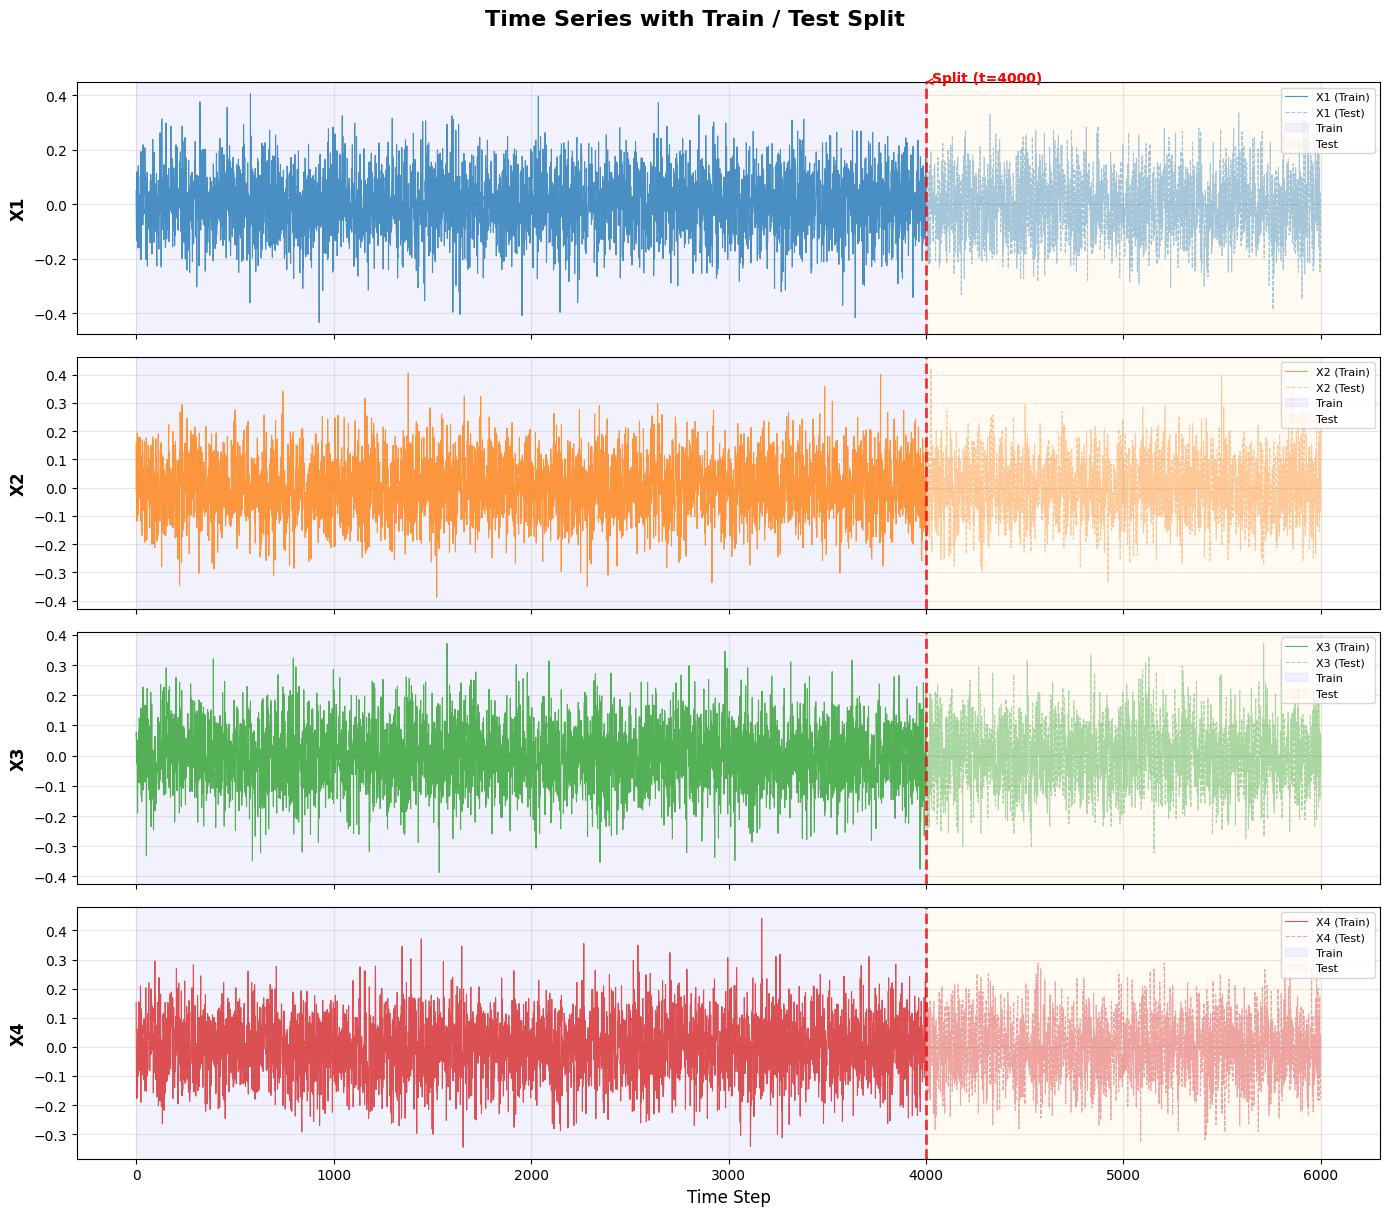


Train: t=0 to t=3999 (4000 points)
Test:  t=4000 to t=5999 (2000 points)


In [ ]:
median_df = (interv_results
             .groupby(['model_type', 'algorithm'])['MAE']
             .median()
             .reset_index()
             .rename(columns={'MAE': 'Median_MAE'}))

pivot_median = median_df.pivot(index='algorithm', columns='model_type', values='Median_MAE')
if 'Traditional' in pivot_median.columns and 'Causal' in pivot_median.columns:
    pivot_median['Improvement_%'] = (
        (pivot_median['Traditional'] - pivot_median['Causal']) / pivot_median['Traditional'] * 100
    )
pivot_median = pivot_median.sort_values('Causal')

print("=" * 70)
print("MEDIAN INTERVENTION MAE  (across all 4 experiments)")
print("=" * 70)
print(pivot_median.round(5).to_string())
print("\nPositive Improvement % → Causal outperforms Traditional under interventions.")
print(f"\nBest causal algorithm:      {pivot_median['Causal'].idxmin()}")
print(f"Best traditional algorithm: {pivot_median['Traditional'].idxmin()}")


## 7. Visualizations


In [ ]:
# ─── Plot 1: Per-experiment + median MAE bar chart ───────────────────────────
n_panels = len(EXPERIMENTS) + 1
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), sharey=False)
fig.suptitle('Intervention MAE: Causal vs Traditional  (per experiment + median)',
             fontsize=14, fontweight='bold')

x = np.arange(len(model_names))
width = 0.35

for panel_idx, exp in enumerate(EXPERIMENTS):
    ax = axes[panel_idx]
    exp_df   = interv_results[interv_results['experiment'] == exp['name']]
    trad_mae = exp_df[exp_df['model_type'] == 'Traditional'].set_index('algorithm')['MAE']
    caus_mae = exp_df[exp_df['model_type'] == 'Causal'].set_index('algorithm')['MAE']

    ax.bar(x - width/2, [trad_mae.get(m, 0) for m in model_names], width,
           label='Traditional', color='tab:red',  alpha=0.7)
    ax.bar(x + width/2, [caus_mae.get(m, 0) for m in model_names], width,
           label='Causal',      color='tab:blue', alpha=0.7)
    ax.set_title(f'{exp["name"]}\n{exp["description"]}', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=7)
    ax.set_ylabel('MAE', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

# Median panel
ax = axes[-1]
trad_med = pivot_median['Traditional']
caus_med = pivot_median['Causal']
ax.bar(x - width/2, [trad_med.get(m, 0) for m in model_names], width,
       label='Traditional', color='tab:red',  alpha=0.7)
ax.bar(x + width/2, [caus_med.get(m, 0) for m in model_names], width,
       label='Causal',      color='tab:blue', alpha=0.7)
ax.set_title('MEDIAN\n(across 4 experiments)', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=7)
ax.set_ylabel('Median MAE', fontsize=9)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ─── Plot 2: Improvement % heatmap ───────────────────────────────────────────
improvement_data = []
for exp in EXPERIMENTS:
    exp_df = interv_results[interv_results['experiment'] == exp['name']]
    for mname in model_names:
        mdf   = exp_df[exp_df['algorithm'] == mname]
        t_mae = mdf[mdf['model_type'] == 'Traditional']['MAE'].values
        c_mae = mdf[mdf['model_type'] == 'Causal']['MAE'].values
        imp = ((t_mae[0] - c_mae[0]) / t_mae[0] * 100
               if len(t_mae) and len(c_mae) and t_mae[0] > 0 else 0)
        improvement_data.append({'Experiment': exp['name'], 'Algorithm': mname,
                                  'Improvement_%': imp})

imp_df    = pd.DataFrame(improvement_data)
imp_pivot = imp_df.pivot(index='Algorithm', columns='Experiment', values='Improvement_%')

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(imp_pivot.values, cmap='RdYlGn', aspect='auto', vmin=-20, vmax=80)
ax.set_xticks(range(len(imp_pivot.columns)))
ax.set_xticklabels(imp_pivot.columns, fontsize=11)
ax.set_yticks(range(len(imp_pivot.index)))
ax.set_yticklabels(imp_pivot.index, fontsize=11)
ax.set_title('Causal Improvement over Traditional  [%]  – Intervention MAE\n'
             '(green = causal better  ·  red = traditional better)',
             fontsize=11, fontweight='bold')
for i in range(len(imp_pivot.index)):
    for j in range(len(imp_pivot.columns)):
        val = imp_pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='black')
plt.colorbar(im, ax=ax, label='Improvement %')
plt.tight_layout()
plt.show()


Models to evaluate: ['RandomForest', 'LinearRegression', 'MLP', 'XGBoost', 'GAM']


In [ ]:
# ─── Plot 3: Error distributions per experiment ──────────────────────────────
fig, axes = plt.subplots(len(EXPERIMENTS), 1,
                          figsize=(13, 4 * len(EXPERIMENTS)), squeeze=False)
fig.suptitle('Absolute Error Distribution: Causal vs Traditional\n'
             '(all algorithms combined per experiment)',
             fontsize=13, fontweight='bold', y=1.01)

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i, 0]
    idf = all_interv_dfs[exp['name']]
    te  = idf['traditional_error'].values
    ce  = idf['causal_error'].values
    bins = np.linspace(0, max(te.max(), ce.max()), 40)

    ax.hist(te, bins=bins, alpha=0.5, color='tab:red',
            label=f'Traditional (mean={te.mean():.4f})')
    ax.hist(ce, bins=bins, alpha=0.5, color='tab:blue',
            label=f'Causal (mean={ce.mean():.4f})')
    ax.set_title(f'{exp["name"]}: {exp["description"]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Plot 4: Error vs intervention magnitude (delta) ─────────────────────────
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(5 * len(EXPERIMENTS), 4), sharey=False)
fig.suptitle('Absolute Error vs Intervention Magnitude  (delta = v - X3_obs)',
             fontsize=13, fontweight='bold')

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    idf = all_interv_dfs[exp['name']]
    ax.scatter(idf['delta'], idf['traditional_error'], alpha=0.15, s=8,
               color='tab:red',  label='Traditional')
    ax.scatter(idf['delta'], idf['causal_error'],      alpha=0.15, s=8,
               color='tab:blue', label='Causal')
    ax.set_title(exp['name'], fontsize=11, fontweight='bold')
    ax.set_xlabel('delta = v - X3_obs')
    ax.set_ylabel('|Error|')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Final summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL SUMMARY — per experiment (all models combined)")
print("=" * 70)
for exp in EXPERIMENTS:
    idf = all_interv_dfs[exp['name']]
    ot  = idf['traditional_error'].mean()
    oc  = idf['causal_error'].mean()
    imp = (ot - oc) / ot * 100 if ot > 0 else 0
    print(f"  [{exp['name']}]  Trad MAE={ot:.4f}  Causal MAE={oc:.4f}  "
          f"Improvement={imp:+.1f}%  -> {'Causal' if imp > 0 else 'Traditional'} wins")


Training and evaluation functions defined.
